In [3]:
import urllib, json

def generate_toc(notebook_path, indent_char="&emsp;"):
    is_markdown = lambda it: "markdown" == it["cell_type"]
    is_title = lambda it: it.strip().startswith("#") and it.strip().lstrip("#").lstrip()

    with open(notebook_path, 'r') as in_f:
        nb_json = json.load(in_f)

    toc_numbers = []  # Lista para llevar el conteo de los números de contenido en cada nivel

    for cell in filter(is_markdown, nb_json["cells"]):
        for line in filter(is_title, cell["source"]):
            line = line.strip()
            title = line.lstrip("#").lstrip()

            level = line.count("#")  # Nivel del título según la cantidad de "#"

            if level > len(toc_numbers):
                toc_numbers.append(1)  # Agregar un nuevo nivel con numeración inicial en 1
            else:
                toc_numbers[level - 1] += 1  # Incrementar el número de contenido en el nivel actual
                toc_numbers[level:] = [1] * (len(toc_numbers) - level)  # Reiniciar numeración en niveles inferiores

            toc_number_str = ".".join(str(num) for num in toc_numbers[:level])
            indent = indent_char * level
            url = urllib.parse.quote(title.replace(" ", "-"))
            out_line = f"{indent}{toc_number_str} [{title}](#{url})<br>\n"
            print(out_line, end="")

generate_toc('/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/06_Classer_images_DL/livrables/notebook.ipynb')

&emsp;1 [Prépartion du dataset](#Pr%C3%A9partion-du-dataset)<br>
&emsp;&emsp;1.1 [Lecture et observation des données](#Lecture-et-observation-des-donn%C3%A9es)<br>
&emsp;&emsp;1.2 [Limitation du nombre de classes](#Limitation-du-nombre-de-classes)<br>
&emsp;&emsp;1.3 [histogrammes des images conservées](#histogrammes-des-images-conserv%C3%A9es)<br>
&emsp;&emsp;1.4 [Pré-traitements](#Pr%C3%A9-traitements)<br>
&emsp;&emsp;1.5 [Chargement des données - création des Datasets et DataLoaders](#Chargement-des-donn%C3%A9es---cr%C3%A9ation-des-Datasets-et-DataLoaders)<br>
&emsp;2 [Modélisation](#Mod%C3%A9lisation)<br>
&emsp;&emsp;2.2 [Essais avec un modèle from scratch (basée sur AlexNet)](#Essais-avec-un-mod%C3%A8le-from-scratch-%28bas%C3%A9e-sur-AlexNet%29)<br>
&emsp;&emsp;&emsp;2.2.1 [Premier entrainement - algorithme similaire à Levenberg-Marquardt](#Premier-entrainement---algorithme-similaire-%C3%A0-Levenberg-Marquardt)<br>
&emsp;&emsp;&emsp;2.2.2 [Entrainement avec learing rate scheduler]

scale: 0.6428571428571429
kernel_size: 3


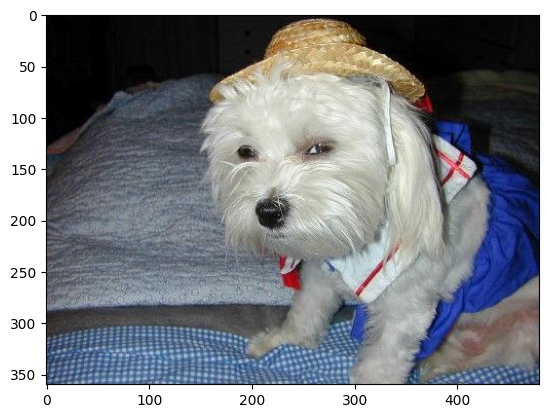

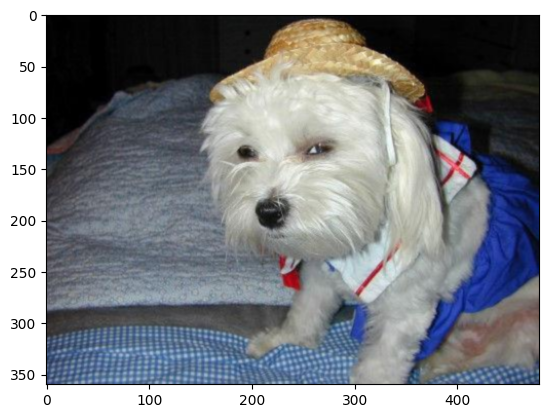

In [21]:
import torch
from torchvision import transforms
from torchvision.io import read_image
import matplotlib.pyplot as plt

# image = torch.zeros((1, 225, 225), dtype=torch.float)
# image[0, 112, 112] = 1.
filename = '../data/source/images/n02085936-Maltese_dog/n02085936_66.jpg'
filename = '../data/source/images/n02085936-Maltese_dog/n02085936_3698.jpg'
image = read_image(filename)

target_shape = (224, 224)
scale = 0.3 * max(image.shape) / max(target_shape)
kernel_size = int(5*scale + 0.5)
print('scale:', scale)
print('kernel_size:', kernel_size)
gblur = transforms.GaussianBlur(kernel_size + (kernel_size+1) % 2, scale)
img_blur = gblur(image)

fig, ax = plt.subplots()
ax.imshow(image.swapaxes(2,0).swapaxes(1,0))

fig, ax = plt.subplots()
ax.imshow(img_blur.swapaxes(2,0).swapaxes(1,0))


# Image interp

In [ ]:
# kernel shape : (1 + 1./step, 1+2*k)
for i, (xp, yp) in enumerate(xyp):
    u, v = int(xp+0.5), int(yp+0.5)
    dx, dy = xp-u, yp-v
    idx = int(dx / step + 0.5)
    idy = int(dy / step + 0.5)
    img_p = kernel[idy:idy+1].dot((img[u-k:u+k+1, v-k:v+k+1] @ kernel[idx]))

In [46]:
kernel = torch.Tensor([1., 2, 3, 4, 5]) # .reshape(-1, 1)
kernel2 = torch.Tensor([7., 8, 9, 10, 11])  # .reshape((1, -1))
A = torch.arange(25, dtype=torch.float).reshape(5, 5)
print('kernel:', kernel.shape, kernel.dtype, kernel.flatten())
print('kernel2:', kernel2.shape, kernel2)
print('A:', A)



ref = A @ kernel.reshape(-1, 1)
print('ref:\n', ref)

ref = A @ kernel
print('ref:\n', ref)
# ref = kernel2 @ ref
ref = (kernel2 * ref).sum()
print('ref:\n', ref)

test = kernel2.dot(A @ kernel)
print('test:', test)
# test = torch.einsum('ij, jk -> ik', A, kernel)
# print('test:\n', test)


kernel: torch.Size([5]) torch.float32 tensor([1., 2., 3., 4., 5.])
kernel2: torch.Size([5]) tensor([ 7.,  8.,  9., 10., 11.])
A: tensor([[ 0.,  1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19.],
        [20., 21., 22., 23., 24.]])
ref:
 tensor([[ 40.],
        [115.],
        [190.],
        [265.],
        [340.]])
ref:
 tensor([ 40., 115., 190., 265., 340.])
ref:
 tensor(9300.)
test: tensor(9300.)


x: tensor([ 4,  3,  2,  1,  0, -1, -2, -3, -4])
tensor([[ 4.0000,  3.0000,  2.0000,  ..., -2.0000, -3.0000, -4.0000],
        [ 4.0010,  3.0010,  2.0010,  ..., -1.9990, -2.9990, -3.9990],
        [ 4.0020,  3.0020,  2.0020,  ..., -1.9980, -2.9980, -3.9980],
        ...,
        [ 4.4980,  3.4980,  2.4980,  ..., -1.5020, -2.5020, -3.5020],
        [ 4.4990,  3.4990,  2.4990,  ..., -1.5010, -2.5010, -3.5010],
        [ 4.5000,  3.5000,  2.5000,  ..., -1.5000, -2.5000, -3.5000]],
       dtype=torch.float64)


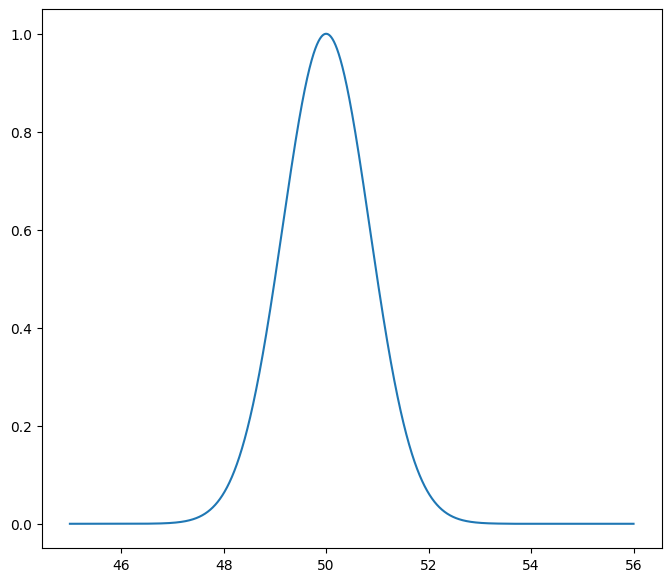

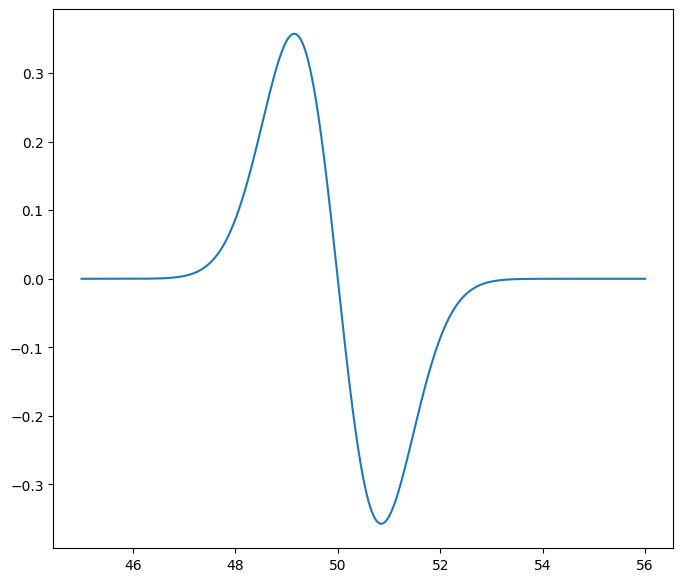

In [86]:
import torch
import matplotlib.pyplot as plt

size = 7
n = size//2
x = torch.arange(n+1, -n-1-1, -1)
print('x:', x)
dx0 = 1e-3
dx = np.arange(0, 0.5+dx0, dx0)
xdx = x.reshape(1, -1) + dx.reshape(-1, 1)
print(xdx)

sigma = 1.2
kernels = torch.exp(-(xdx*xdx) / (sigma**2))
kernels_dx = (-xdx/(sigma**2) * kernels)
kernels = kernels[:, 1:-1].float()
kernels_dx = kernels_dx.float()

y = torch.zeros(101)
y[50] = 1.

def interp(y, x):
    x0 = int(x + 0.5)
    dx = x - x0
    x0 -= n
    if dx < 0:
        dx = abs(dx)
        kernel = kernels[int(dx/dx0+0.5)].flip(0)
        return  kernel.dot(y[x0: x0+size])
    kernel = kernels[int(dx/dx0+0.5)]
    return kernel.dot(y[x0: x0+size])

def interp_dx(y, x):
    x0 = int(x + 0.5)
    dx = x - x0
    x0 -= n+1
    if dx < 0:
        dx = abs(dx)
        kernel = -kernels_dx[int(dx/dx0+0.5)].flip(0)
        return  kernel.dot(y[x0: x0+size+2])
    kernel = kernels_dx[int(dx/dx0+0.5)]
    return kernel.dot(y[x0: x0+size+2])

x_interp = torch.arange(45, 56, dx0)
y_interp = [interp(y, xi) for xi in x_interp]

x2 = torch.arange(45, 56)
y2 = torch.exp( -(x2-50)**2/sigma**2)
if True:
    fig, ax = plt.subplots(figsize=(8,7))
    # ax.plot(x2, y2, 'o')
    # ax.plot(xdx[:, 1:-1].flatten() + 50, kernels.flatten(), 'o')
    # ax.plot(x2, y[x2], 'o')
    ax.plot( x_interp, y_interp)

y_dx_interp = [interp_dx(y, xi) for xi in x_interp]

y2_dx = -(x2-50)/sigma**2 * y2
fig, ax = plt.subplots(figsize=(8,7))
# ax.plot( xdx.flatten() + 50, kernels_dx.flatten(), 'o')
# ax.plot(x2, y2_dx, 'o')
ax.plot( x_interp, y_dx_interp)

img: torch.Size([31, 31])
u: torch.Size([1000])
v: torch.Size([1000])
grid: torch.Size([1000, 2])
grid min uv: torch.return_types.min(
values=tensor([ 0., 15.]),
indices=tensor([0, 0]))
grid max uv: torch.return_types.max(
values=tensor([29., 15.]),
indices=tensor([999,   0]))

grid min uv: torch.return_types.min(
values=tensor([-1.,  0.]),
indices=tensor([0, 0]))
grid max uv: torch.return_types.max(
values=tensor([0.9333, 0.0000]),
indices=tensor([999,   0]))

values: torch.Size([1000])
img: torch.Size([31, 31])
img[u0:u1+1, v0]: torch.Size([30])
img[u0:u1+1, v0]: tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0035, 0.0431, 0.1932, 0.3185, 0.1932, 0.0431,
        0.0035, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000])
grid.flip(-1): torch.Size([1000, 2])


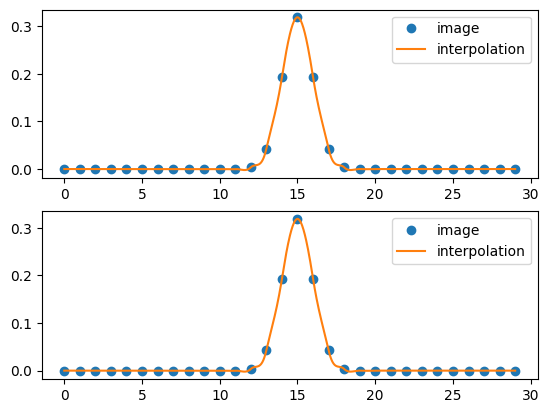

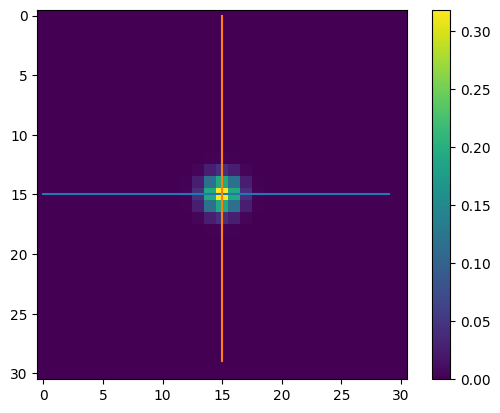

In [38]:
import torch
import torch.nn.functional as F
from torch import pi
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt


x = torch.linspace(0, 100, 31)
y = torch.linspace(0, 100, 31)

yy, xx = torch.meshgrid(x, y, indexing='ij')

# print('xx:\n', xx)

# img = torch.cos((2*pi/100.)*xx) * torch.exp(xx*xx * (np.log(0.001)/100000))
# img += torch.cos((2*pi/220.)*yy) * torch.exp(yy*yy * (np.log(0.001)/100000))

img = torch.zeros_like(xx)
img[15, 15] = 2.
img = transforms.GaussianBlur(7, 1.)(img.reshape((1,) + img.shape))[0]
print('img:', img.shape)

u0, u1 = 0, 29
v0 = 15
u = torch.linspace(u0, u1, 1000)
v = torch.full(u.shape, v0)

# grid = torch.concat(
#     (
#         (v/(2*len(y))-1.).reshape(-1, 1),
#         (u/(2*len(x))-1.).reshape(-1, 1)
#     ),
#     dim=1)
print('u:', u.shape)
print('v:', v.shape)

grid = torch.stack([u, v], dim=-1)
print('grid:', grid.shape)

print('grid min uv:', grid.min(0))
print('grid max uv:', grid.max(0))


def normalize_for_grid(x, width):
    return x / (0.5*(width-1)) - 1.

grid[:, 0] = normalize_for_grid(grid[:, 0], img.shape[1])
grid[:, 1] = normalize_for_grid(grid[:, 1], img.shape[0])

print('')
print('grid min uv:', grid.min(0))
print('grid max uv:', grid.max(0))

print('')
values = F.grid_sample(
    img.reshape((1, 1) + img.shape),
    grid.reshape((1, 1) + grid.shape),
    mode='bicubic',
    # mode='bilinear',
    align_corners=True).flatten()

print('values:', values.shape)

init_array = img[v0, u0:u1+1]
print('img:', img.shape)
print('img[u0:u1+1, v0]:', init_array.shape)
print('img[u0:u1+1, v0]:', init_array)
fig, axs = plt.subplots(nrows=2)
axs[0].plot(np.arange(u0, u1+1), init_array.numpy(), 'o', label='image')
axs[0].plot(u, values, label='interpolation')
axs[0].legend()

# ! image is square so ok
values = F.grid_sample(
    img.reshape((1, 1) + img.shape),
    grid.flip(-1).reshape((1, 1) + grid.shape),
    mode='bicubic',
    align_corners=True
).flatten()
print('grid.flip(-1):', grid.flip(-1).shape)

init_array = img[u0:u1+1, v0]
axs[1].plot(np.arange(u0, u1+1), init_array.numpy(), 'o', label='image')
axs[1].plot(u, values, label='interpolation')
axs[1].legend()

fig, ax = plt.subplots()
im = ax.imshow(img.numpy())
ax.plot(np.arange(u0, u1+1), [v0,]*(u1+1-u0))
ax.plot([v0,]*(u1+1-u0), np.arange(u0, u1+1))
fig.colorbar(im)


In [64]:
help(torch.full)

Help on built-in function full in module torch:

full(...)
    full(size, fill_value, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False) -> Tensor
    
    Creates a tensor of size :attr:`size` filled with :attr:`fill_value`. The
    tensor's dtype is inferred from :attr:`fill_value`.
    
    Args:
        size (int...): a list, tuple, or :class:`torch.Size` of integers defining the
            shape of the output tensor.
        fill_value (Scalar): the value to fill the output tensor with.
    
    Keyword args:
        out (Tensor, optional): the output tensor.
        dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
            Default: if ``None``, uses a global default (see :func:`torch.set_default_tensor_type`).
        layout (:class:`torch.layout`, optional): the desired layout of returned Tensor.
            Default: ``torch.strided``.
        device (:class:`torch.device`, optional): the desired device of return

In [52]:
import torch.multiprocessing as mp

num_cores = mp.cpu_count()
print(num_cores)
help(A.share_memory_)
# batch_size, channels, height, width = x.shape
# x.share_memory_()
# pool = mp.Pool(processes=num_cores)
# results = [pool.apply(some_function.apply, args=(x[b, c],)) for b in range(batch_size) for c in range(channels)]
# pool.close()
# pool.join()
# out = torch.stack(results).reshape(batch_size, channels, height, width)

10
Help on method share_memory_ in module torch._tensor:

share_memory_() method of torch.Tensor instance
    Moves the underlying storage to shared memory.
    
    This is a no-op if the underlying storage is already in shared memory
    and for CUDA tensors. Tensors in shared memory cannot be resized.



# DenseNet

In [1]:
import torchvision

model = torchvision.models.DenseNet(
    growth_rate = 16, # how many filters to add each layer (`k` in paper)
    block_config = (6, 12, 24, 16), # how many layers in each pooling block
    num_init_features = 16, # the number of filters to learn in the first convolution layer (k0)
    bn_size= 4, # multiplicative factor for number of bottleneck (1x1 cons) layers
    drop_rate = 0, # dropout rate after each dense conv layer
    num_classes = 30 # number of classification classes
)

print(model) # see snapshot below

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 16, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1):

In [4]:
from torch import nn
linear = nn.Linear(2,3)
linear.weight.shape

torch.Size([3, 2])

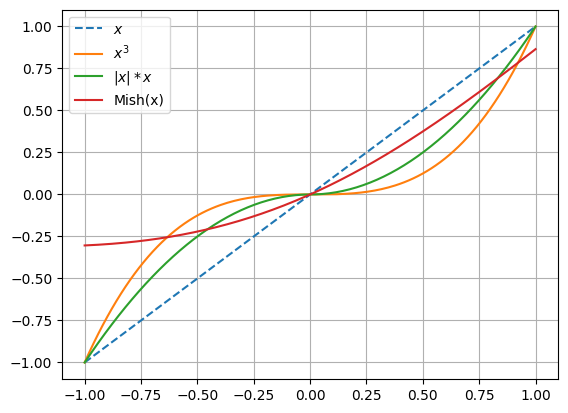

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

x = np.linspace(-1, 1, 200)
fig, ax = plt.subplots()
ax.plot(x, x, '--', label=r'$x$')
ax.plot(x, x**3, label=r'$x^3$')
ax.plot(x, np.abs(x)*x, label=r'$|x|*x$')
ax.plot(x, nn.Mish()(torch.Tensor(x)), label='Mish(x)')
ax.grid()
ax.legend()

In [17]:
import torchvision
model = torchvision.models.densenet121()
print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [12]:
torch.sign(torch.Tensor(x))

tensor([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  

# Backpropagation

/tmp/ipykernel_38000/1780503862.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['species_n'] = iris.species.map({'versicolor':1, 'virginica':2})


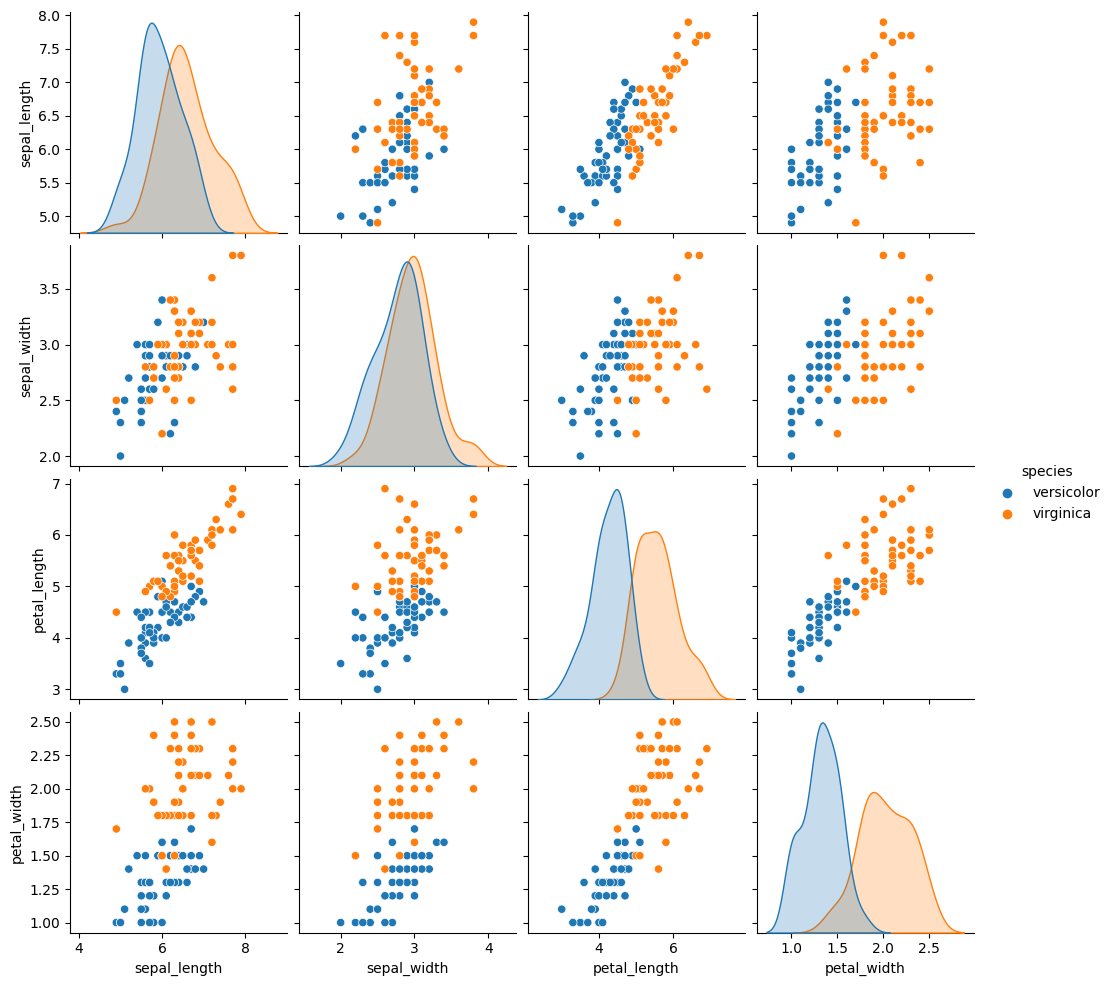

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection

iris = sns.load_dataset("iris")
#g = sns.pairplot(iris, hue="species")
df = iris[iris.species != "setosa"]
g = sns.pairplot(df, hue="species")
df['species_n'] = iris.species.map({'versicolor':1, 'virginica':2})

# Y = 'petal_length', 'petal_width'; X = 'sepal_length', 'sepal_width')
X_iris = np.asarray(df.loc[:, ['sepal_length', 'sepal_width']], dtype=np.float32)
Y_iris = np.asarray(df.loc[:, ['petal_length', 'petal_width']], dtype=np.float32)
label_iris = np.asarray(df.species_n, dtype=int)

# Scale
from sklearn.preprocessing import StandardScaler
scalerx, scalery = StandardScaler(), StandardScaler()
X_iris = scalerx.fit_transform(X_iris)
Y_iris = StandardScaler().fit_transform(Y_iris)

# Split train test
X_iris_tr, X_iris_val, Y_iris_tr, Y_iris_val, label_iris_tr, label_iris_val = \
    sklearn.model_selection.train_test_split(X_iris, Y_iris, label_iris, train_size=0.5, stratify=label_iris)

## numpy

0 8913.06538530005 1443.0641052927533
10 116.1023158555486 167.84697821959276
20 70.13825391492631 91.67720332234043
30 56.47266016468656 65.78448705438397
40 51.597157835015466 56.33076447226078


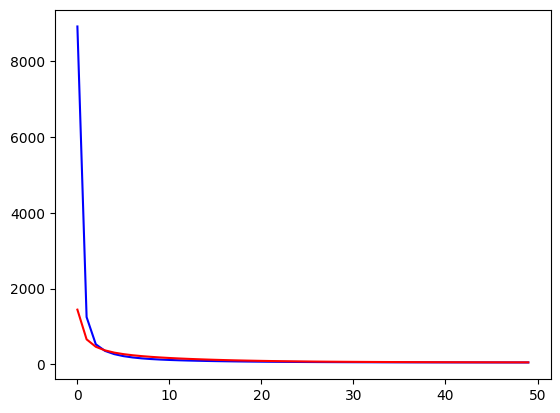

In [2]:
# X=X_iris_tr; Y=Y_iris_tr; X_val=X_iris_val; Y_val=Y_iris_val

def two_layer_regression_numpy_train(X, Y, X_val, Y_val, lr, nite):
    # N is batch size; D_in is input dimension;
    # H is hidden dimension; D_out is output dimension.
    # N, D_in, H, D_out = 64, 1000, 100, 10
    N, D_in, H, D_out = X.shape[0], X.shape[1], 100, Y.shape[1]

    W1 = np.random.randn(D_in, H)
    W2 = np.random.randn(H, D_out)

    losses_tr, losses_val = list(), list()

    learning_rate = lr
    for t in range(nite):
        # Forward pass: compute predicted y
        z1 = X.dot(W1)
        h1 = np.maximum(z1, 0)
        Y_pred = h1.dot(W2)

        # Compute and print loss
        loss = np.square(Y_pred - Y).sum()

        # Backprop to compute gradients of w1 and w2 with respect to loss
        grad_y_pred = 2.0 * (Y_pred - Y)
        grad_w2 = h1.T.dot(grad_y_pred)
        grad_h1 = grad_y_pred.dot(W2.T)
        grad_z1 = grad_h1.copy()
        grad_z1[z1 < 0] = 0
        grad_w1 = X.T.dot(grad_z1)

        # Update weights
        W1 -= learning_rate * grad_w1
        W2 -= learning_rate * grad_w2

        # Forward pass for validation set: compute predicted y
        z1 = X_val.dot(W1)
        h1 = np.maximum(z1, 0)
        y_pred_val = h1.dot(W2)
        loss_val = np.square(y_pred_val - Y_val).sum()

        losses_tr.append(loss)
        losses_val.append(loss_val)

        if t % 10 == 0:
            print(t, loss, loss_val)

    return W1, W2, losses_tr, losses_val

W1, W2, losses_tr, losses_val = two_layer_regression_numpy_train(X=X_iris_tr, Y=Y_iris_tr, X_val=X_iris_val, Y_val=Y_iris_val,
                                                                 lr=1e-4, nite=50)
plt.plot(np.arange(len(losses_tr)), losses_tr, "-b", np.arange(len(losses_val)), losses_val, "-r")

## torch (without autograd)

0 17471.0078125 5738.93896484375
10 131.26988220214844 145.16033935546875
20 89.76087188720703 103.94970703125
30 80.03524017333984 90.77915954589844
40 73.8621597290039 82.81712341308594


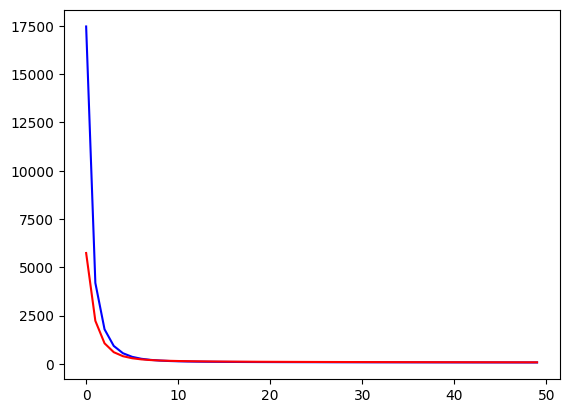

In [3]:
import torch

# X=X_iris_tr; Y=Y_iris_tr; X_val=X_iris_val; Y_val=Y_iris_val

def two_layer_regression_tensor_train(X, Y, X_val, Y_val, lr, nite):

    dtype = torch.float
    device = torch.device("cpu")
    # device = torch.device("cuda:0") # Uncomment this to run on GPU

    # N is batch size; D_in is input dimension;
    # H is hidden dimension; D_out is output dimension.
    N, D_in, H, D_out = X.shape[0], X.shape[1], 100, Y.shape[1]

    # Create random input and output data
    X = torch.from_numpy(X)
    Y = torch.from_numpy(Y)
    X_val = torch.from_numpy(X_val)
    Y_val = torch.from_numpy(Y_val)

    # Randomly initialize weights
    W1 = torch.randn(D_in, H, device=device, dtype=dtype)
    W2 = torch.randn(H, D_out, device=device, dtype=dtype)

    losses_tr, losses_val = list(), list()

    learning_rate = lr
    for t in range(nite):
        # Forward pass: compute predicted y
        z1 = X.mm(W1)
        h1 = z1.clamp(min=0)
        y_pred = h1.mm(W2)

        # Compute and print loss
        loss = (y_pred - Y).pow(2).sum().item()

        # Backprop to compute gradients of w1 and w2 with respect to loss
        grad_y_pred = 2.0 * (y_pred - Y)
        grad_w2 = h1.t().mm(grad_y_pred)
        grad_h1 = grad_y_pred.mm(W2.t())
        grad_z1 = grad_h1.clone()
        grad_z1[z1 < 0] = 0
        grad_w1 = X.t().mm(grad_z1)

        # Update weights using gradient descent
        W1 -= learning_rate * grad_w1
        W2 -= learning_rate * grad_w2

        # Forward pass for validation set: compute predicted y
        z1 = X_val.mm(W1)
        h1 = z1.clamp(min=0)
        y_pred_val = h1.mm(W2)
        loss_val = (y_pred_val - Y_val).pow(2).sum().item()

        losses_tr.append(loss)
        losses_val.append(loss_val)

        if t % 10 == 0:
            print(t, loss, loss_val)

    return W1, W2, losses_tr, losses_val

W1, W2, losses_tr, losses_val = two_layer_regression_tensor_train(X=X_iris_tr, Y=Y_iris_tr, X_val=X_iris_val, Y_val=Y_iris_val,
                                                                 lr=1e-4, nite=50)

plt.plot(np.arange(len(losses_tr)), losses_tr, "-b", np.arange(len(losses_val)), losses_val, "-r")

# Autre

In [1]:
import torch
import torchvision.transforms as transforms

In [ ]:
from torchvision.models import resnext50_32x4d, ResNeXt50_32X4D_Weights


In [29]:
import torch
import torch.nn as nn

class MyModule(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(in_features, out_features, bias=False),
            nn.Sequential(
                nn.Conv1d(in_channels=out_features, out_channels=out_features,
                          kernel_size=3),
                nn.BatchNorm1d(out_features)
            )
        )
        # print('a initial:\n', self.a.weight)
        # Register a hook on self.a
        # self.a.weight.register_hook(self.update_a)

    def forward(self, x):
        # print('FORWARD self.a:\n', self.a.weight)
        return self.a(x)

    def update_a(self, grad):
        # Define the update logic for self.a
        # You can modify self.a based on the gradients or any other logic
        # self.a = self.a + 0.1 * grad  # Example update logic
        print('\nHOOK A')
        # print('self.a:\n', self.a.weight)
        # with torch.no_grad():
        #     self.a.weight.add_(0.01)
        # print('self.a:\n', self.a.weight)
        

# Example usage
model = MyModule(2, 2)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


def loop_over_sequence(seq):
    print('\nLOOP OVER SEQUENCE')
    for elem in seq:
        print(type(elem))
        if type(elem) == nn.Sequential:
            loop_over_sequence(elem)

loop_over_sequence(model.seq)


x = torch.randn(10, 2)
target = x * (2. + -3*x)
compute_loss = nn.MSELoss()
num_epochs = 3

if False:
    model.train()
    # Training loop
    for _ in range(num_epochs):
        optimizer.zero_grad()
        output = model(x)

        print('\nloss')
        loss = compute_loss(output, target)
        print('loss.backward')
        print(model.a.weight)
        loss.backward()
        print('optimizer.step')
        print(model.a.weight)
        optimizer.step()
        print('end of iter')
        print(model.a.weight)

        # The update_a function will be automatically called after optimizer.step()
        # You can access the updated value of self.a here
        # updated_a = model.a



LOOP OVER SEQUENCE
<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.container.Sequential'>

LOOP OVER SEQUENCE
<class 'torch.nn.modules.conv.Conv1d'>
<class 'torch.nn.modules.batchnorm.BatchNorm1d'>


In [100]:
import torch
import numpy as np
t = torch.arange(48, dtype=float).reshape(2,2,3,4)
for i in range(4):
    a = np.arange( 12*(i), 12*(i+1))
    print(a.sum(), a.mean(), ((a-a.mean())**2).sum())
    

def center_tensor2d(t):
    t.add_(-t.mean((-1,-2)).reshape(t.shape[:-2] + (1,1)))


def normalize_centered_tensor(t):
    t.mul_((1./torch.sqrt((t*t).sum((-1, -2)))).reshape(t.shape[:-2]+(1, 1)))

print(t)
print(t.sum())
# print(t.mean((-1,-2)), t.mean((-1,-2)).shape)
center_tensor2d(t)
# print(t.mean((-1,-2)), t.mean((-1,-2)).shape)

print((t*t).sum((-1, -2)))
normalize_centered_tensor(t)
print((t*t).sum((-1, -2)))

66 5.5 143.0
210 17.5 143.0
354 29.5 143.0
498 41.5 143.0
tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.]],

         [[12., 13., 14., 15.],
          [16., 17., 18., 19.],
          [20., 21., 22., 23.]]],


        [[[24., 25., 26., 27.],
          [28., 29., 30., 31.],
          [32., 33., 34., 35.]],

         [[36., 37., 38., 39.],
          [40., 41., 42., 43.],
          [44., 45., 46., 47.]]]], dtype=torch.float64)
tensor(1128., dtype=torch.float64)
tensor([[143., 143.],
        [143., 143.]], dtype=torch.float64)
tensor([[1., 1.],
        [1., 1.]], dtype=torch.float64)


tensor(-0.9997)
tensor(-0.0027)
tensor(-0.0027)


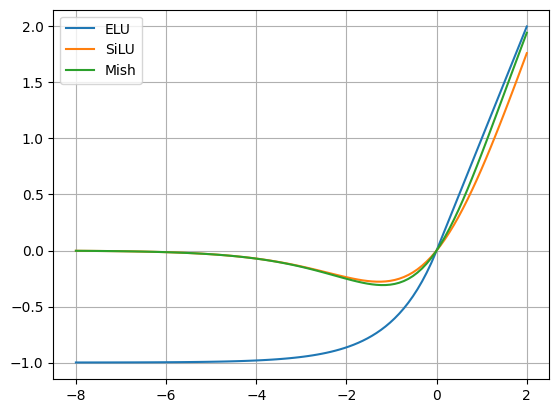

In [94]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

x = torch.linspace(-8, 2, 100)

fig, ax = plt.subplots()
for (func, label) in [(nn.ELU(), 'ELU'),
                      (nn.SiLU(), 'SiLU'),
                      (nn.Mish(), 'Mish'),
                      ]:
    y = func(x)
    ax.plot(x.numpy(), y.numpy(), label=label)
    print(y[0])
ax.grid(visible=True)
ax.legend()

In [107]:
import numpy as np

a = np.random.random(30)
seek = ( (a-a.mean())**2 ).sum()
print( seek )
print()
print( '1:', (a*a).sum() )
# print( a.mean()**2 )
print( '2:', a.sum()**2 / 30 )
print( '3:', (a*a).mean() )
val = (a*a).sum() - a.sum()**2 / a.size
print( val )
print()
print(val-seek)

2.5191687406383023

1: 7.2847973329341755
2: 4.765628592295873
3: 0.24282657776447253
2.5191687406383023

0.0


# ZNCC

In [3]:
import torch.nn as nn
seq = nn.Sequential(
    nn.Conv2d(3, 5, 3),
    nn.MaxPool2d(3)
)
print(seq)
for layer in seq:
    print(isinstance(layer, nn.Conv2d))

Sequential(
  (0): Conv2d(3, 5, kernel_size=(3, 3), stride=(1, 1))
  (1): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
)
True
False


In [2]:
import torch.nn.functional as F
help(F.conv2d)

Help on built-in function conv2d in module torch:

conv2d(...)
    conv2d(input, weight, bias=None, stride=1, padding=0, dilation=1, groups=1) -> Tensor
    
    Applies a 2D convolution over an input image composed of several input
    planes.
    
    This operator supports :ref:`TensorFloat32<tf32_on_ampere>`.
    
    See :class:`~torch.nn.Conv2d` for details and output shape.
    
    Note:
        In some circumstances when given tensors on a CUDA device and using CuDNN, this operator may select a nondeterministic algorithm to increase performance. If this is undesirable, you can try to make the operation deterministic (potentially at a performance cost) by setting ``torch.backends.cudnn.deterministic = True``. See :doc:`/notes/randomness` for more information.
    
    Note:
        This operator supports complex data types i.e. ``complex32, complex64, complex128``.
    
    
    Args:
        input: input tensor of shape :math:`(\text{minibatch} , \text{in\_channels} , iH , iW)

In [1]:
import torch
import torch.nn as nn
import numpy as np
from scipy.stats import pearsonr

import torch.nn.functional as F

def init_he(layer):
    with torch.no_grad():
        # He, recommanded with (leaky) relu only (pytorch)
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in',
                                 nonlinearity='leaky_relu')
        if hasattr(layer, 'bias') and (layer.bias is not None):
            nn.init.constant_(layer.bias, 0.)

def center_tensor3d(t):
    t.add_(-t.mean((-1, -2, -3), keepdim=True))


def normalize_tensor3d(t):
    factors = 1. / torch.sqrt((t*t).sum((-1, -2, -3), keepdim=True))
    t.mul_(factors)


class ZNCC2d(nn.Module):
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 kernel_size: int,
                 stride: int,
                 padding: int,
                 sublayers: int = 1,
                 bias: bool = True,
                 BatchNorm: bool = False,
                 activation: str = None):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)
        self.BatchNorm = BatchNorm
        self.activation = activation
        # self.pattern = nn.Conv2d(
        #     in_channels=in_channels,
        #     out_channels=out_channels,
        #     kernel_size=kernel_size,
        #     stride=stride,
        #     padding=padding,
        #     bias=False
        # )
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size,) * 2
        self.paddings_ = ((kernel_size[1]-1),)*2 + ((kernel_size[0]-1),)*2
        self.dirac = torch.zeros((in_channels, in_channels,
                                  2*kernel_size[0]-1,
                                  2*kernel_size[1]-1),
                                 dtype=torch.float)
        for i in range(self.in_channels):
                self.dirac[i, i, kernel_size[0]-1, kernel_size[1]-1] = 1.
        layer = [nn.Conv2d(
            in_channels=in_channels if i == 0 else out_channels,
            out_channels=out_channels,
            kernel_size=[k - 2*(sublayers-1) for k in kernel_size]
            if i == 0 else 3,
            stride=stride if i == sublayers-1 else 1,
            padding=padding if i == 0 else 0,
            groups=1 if i == 0 else out_channels,
            bias=False,
        ) for i in range(sublayers)]
        for cl in layer:
            init_he(cl)
        self.patterns = nn.Sequential(*layer)
        self.sum2d = nn.AvgPool2d(
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            divisor_override=1,
        )
        self.sum2d_ = nn.AvgPool2d(
            kernel_size=3,
            stride=1,
            padding=2,
            divisor_override=1,
        )
        self.size_ = kernel_size**2 if isinstance(kernel_size, int)\
            else kernel_size[0] * kernel_size[1]
        self.size_ *= in_channels
        self.reset_parameters()
        # self.center_norm_pattern()
        final = []
        if BatchNorm:
            final.append(nn.BatchNorm(out_channels))
        if activation is not None:
            final.append(activations[activation])
        if len(final) == 0:
            self.final = nn.Identity()
        else:
            self.final = nn.Sequential(*final)

    def reset_parameters(self):
        # nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        for layer in self.patterns:
            init_he(layer)
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1. / torch.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def get_patterns(self):
        with torch.no_grad():
            patterns = self.patterns(self.dirac)
        return patterns

    def center_norm_pattern(self):
        with torch.no_grad():
            for layer in self.patterns:
                # keep small weights
                normalize_tensor3d(layer.weight)

            # normalize each composed filter
            patterns = self.get_patterns()
            self.avg = patterns.mean((-1, -2, 0), keepdim=True)

            patterns.add_(-self.avg)
            factors = 1. / torch.sqrt((patterns*patterns).sum((-1, -2, 0),
                                                               keepdim=True))
            # print('factors:', factors.shape)
            # print('weight:', self.patterns[0].weight.shape)
            self.patterns[0].weight.data *= factors.reshape(-1, 1, 1, 1)
            # self.avg = self.get_patterns().mean((-1, -2, 0)).reshape(-1, 1, 1)
            self.avg *= factors.reshape(-1, 1, 1)


    def forward(self, x):
        # Conv2d patterns
        print('\nx:', x.shape)
        x = F.pad(x, pad=self.paddings_, mode='constant', value=0.)
        print('x padded:', x.shape)
        # print(x)
        Hx = self.patterns(x)
        sum_x2 = self.sum2d(x*x).sum(-3, keepdim=True)
        sum_x = self.sum2d(x).sum(-3, keepdim=True)
        print('Hx:', Hx.shape)
        print('sum_2d:', self.sum2d(x).shape)
        # print('sum_x:', sum_x)
        print('sum_x2 :', sum_x2.shape)
        # print('sum_x2:', sum_x2)
        print('self.size_:', self.size_)
        print('avg:', self.avg.shape)
        print('self.avg * sum_x', (self.avg * sum_x).shape)
        print('Hx:\n', Hx[0,0,]) # 6:-6, 6:-6])
        # print('avg:\n', self.avg)
        # print('avg * sum_x:\n', (self.avg * sum_x).flatten())
        print('numerator:', (Hx - self.avg * sum_x))
        print('denominator:', torch.sqrt((sum_x2 - (sum_x*sum_x)/self.size_)))
        # print('denom:', torch.sqrt((sum_x2 - (sum_x*sum_x)/self.size_)))
        # print('Hx - self.avg * sum_x:', Hx - self.avg * sum_x)
        Hx = Hx - self.avg * sum_x
        out = Hx / torch.sqrt((sum_x2 - (sum_x*sum_x)/self.size_))
        out = out[:, :,
                  self.paddings_[1]:-self.paddings_[1],
                  self.paddings_[0]:-self.paddings_[0]]
        if self.bias:
            out = out + self.bias
        return self.final(out)


sublayers = 3
out_channels = 1
kernel_size = 7
C = 3
correlator = ZNCC2d(
    in_channels=C, out_channels=out_channels,
    kernel_size=kernel_size, stride=1,
    padding=0, sublayers=sublayers, bias=False)
print(correlator.patterns)
w0 = correlator.patterns[0].weight
print('w0:', w0.shape)
if sublayers > 1:
    w1 = correlator.patterns[1].weight
    print('w1:', w1.shape)
if sublayers > 2:
    w2 = correlator.patterns[2].weight
    print('w2:', w2.shape)
with torch.no_grad():
    w0[:] = 0.0
    w0[0, 0, 0, 1] = 1.
    w0[0, 1, 1, :] = 2.
    w0[0, 2, :, 2] = -1.
    print(w0)

    if sublayers > 1:
        w1[:] = 0.01
        w1[0,:,:,:] = 1.
        w1[0,:,1,2] = 0.

    if sublayers > 2:
        w2[:] = 0.
        w2[0, 0, 0, 0] = -1.
        w2[0, 0, -1, :] = -1.


# dirac = torch.zeros((5,5))
# dirac[2,2] = 1
# print('dirac:')
# print(dirac)

# print('conv(dirac):')
# print(correlator.patterns(dirac.reshape(1,C,5, 5)))
print('')
print('w0:', w0.detach().numpy().sum())
if sublayers > 1:
    print('w1:', w1.detach().numpy().sum())
if sublayers > 2:
    print('w2:', w2.detach().numpy().sum())
print('')
w = correlator.get_patterns()[:, 0].detach()
print('w:', w.shape)
print('w:', w.mean((-1,-2,-3)), (w**2).sum((-1,-2,-3)))
# print(w)
t = w.clone().flip((-1, -2))
t = 2. * t + 3 + 0.2 * torch.randn(t.shape)

print('t:')
print(t)

w -= w.mean((-1,-2,-3), keepdim=True)
w /= np.sqrt((w**2).sum((-1,-2,-3), keepdim=True))

correlator.center_norm_pattern()

w2 = correlator.get_patterns()[:,0].detach()
print('w:', w.mean((-1,-2,-3)), (w**2).sum((-1,-2,-3)))
print('w2:', w2.mean((-1,-2,-3)), ((w2-w2.mean())**2).sum((-1,-2,-3)))

def compute_correl2(x, y):
        print('\nx:', x.shape, 'y:', y.shape)
        # print('x:')
        # print(x)
        xi, yi = x.flatten(), y.flatten()
        print('sum xi*yi:', (xi*yi).sum())
        print('<xi> * sum yi:', (xi.mean()*yi.sum()))
        xi_2 = ((xi-xi.mean())**2).sum()
        yi_2 = ((yi-yi.mean())**2).sum()
        print('numerator:', (xi*yi).sum() - xi.mean()*yi.sum())
        print('denominator:', np.sqrt(xi_2*yi_2))
        # print('xi_2:', xi_2)
        # print('yi_2:', yi_2)
        # print('sqrt(yi_2):', np.sqrt(yi_2))
        # print('sum yi**2:', (yi**2).sum())
        # print('sum yi:', yi.sum())
        return ((xi*yi).sum() - xi.mean()*yi.sum()) / np.sqrt(xi_2*yi_2)


y = correlator(t.reshape(1, C, kernel_size, kernel_size))
print('y:', y.shape)
print('y:', y)
ref = compute_correl2(w2.flip((-1, -2)), t)
print('ref:', ref)
if False:

    w3 = correlator.get_patterns().detach().clone()
    print('w3:', w3.shape)
    # print(w3)
    t = w2.detach().clone() #+ 5 + .2*torch.randn(w2.shape)
    t = t.reshape(1, C, kernel_size, kernel_size)
    print('t:', t.shape)
    # print(t)
    y = correlator(t)
    print('y:', y.shape)
    print(y)

    def compute_correl(x, y):
        xi, yi = x.flatten(), y.flatten()
        xi -= x.mean()
        yi -= y.mean()
        return ( xi * yi ).sum() / np.sqrt( (xi*xi).sum() * (yi*yi).sum() )

    

    # ref2 = compute_correl(w.detach(), t.detach())
    # print( 'ref2:', ref2 )

    ref3 = compute_correl2(w2.detach(), t.detach())
    print( 'ref3:', ref3 )

    ref = pearsonr( w.detach().clone().flatten(), t.flatten() )
    print('ref:', ref )

Sequential(
  (0): Conv2d(3, 1, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (2): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), bias=False)
)
w0: torch.Size([1, 3, 3, 3])
w1: torch.Size([1, 1, 3, 3])
w2: torch.Size([1, 1, 3, 3])
Parameter containing:
tensor([[[[ 0.,  1.,  0.],
          [ 0.,  0.,  0.],
          [ 0.,  0.,  0.]],

         [[ 0.,  0.,  0.],
          [ 2.,  2.,  2.],
          [ 0.,  0.,  0.]],

         [[ 0.,  0., -1.],
          [ 0.,  0., -1.],
          [ 0.,  0., -1.]]]], requires_grad=True)

w0: 4.0
w1: 8.0
w2: -4.0

w: torch.Size([3, 7, 7])
w: tensor(-0.8707) tensor(2458.)
t:
tensor([[[  2.9225,   0.9992,   0.6439,   0.5788,   2.8568,   2.9354,   2.9115],
         [  3.2374,   0.7397,   0.7932,   2.6752,   2.9231,   2.9254,   2.9196],
         [  2.7412,  -0.7066,  -2.8415,  -4.7581,  -1.4081,   1.0056,   2.8096],
         [  2.6541,   1.1044,  -1.1319,  -1.2190,   1.0558,   3.0475,   2.7

In [66]:
import torch
import torch.nn as nn
import numpy as np
from scipy.stats import pearsonr

def init_he(layer):
    with torch.no_grad():
        # He, recommanded with (leaky) relu only (pytorch)
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in',
                                 nonlinearity='leaky_relu')
        if hasattr(layer, 'bias') and (layer.bias is not None):
            nn.init.constant_(layer.bias, 0.)

def center_tensor3d(t):
    t.add_(-t.mean((-1, -2, -3), keepdim=True))


def normalize_centered_tensor3d(t):
    factors = 1. / torch.sqrt((t*t).sum((-1, -2, -3), keepdim=True))
    t.mul_(factors)


class ZNCC2d(nn.Module):
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 kernel_size: int,
                 stride: int,
                 padding: int,
                 bias: bool = True):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)
        self.pattern = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=False
        )
        self.sum2d = nn.AvgPool2d(
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            divisor_override=1,
        )
        self.sum2d_ = nn.AvgPool2d(
            kernel_size=3,
            stride=1,
            padding=2,
            divisor_override=1,
        )
        self.size_ = kernel_size**2 if isinstance(kernel_size, int)\
            else kernel_size[0] * kernel_size[1]
        self.size_ *= in_channels
        self.reset_parameters()
        self.center_norm_pattern()

    def reset_parameters(self):
        # nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        init_he(self.pattern)
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1. / torch.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def center_norm_pattern(self):
        with torch.no_grad():
            self.pattern.weight.add_(-self.pattern.weight.mean((-1, -2, -3),
                                                               keepdim=True))
            normalize_centered_tensor3d(self.pattern.weight)

    def forward(self, x):
        # Conv2d patterns
        Hx = self.pattern(x)
        sum_x2 = self.sum2d(x*x).sum(-3, keepdim=True)
        sum_x = self.sum2d(x).sum(-3, keepdim=True)
        out = Hx / torch.sqrt((sum_x2 - (sum_x*sum_x)/self.size_))
        if self.bias:
            return out + self.bias
        return out


correlator = ZNCC2d(in_channels=3, out_channels=4, kernel_size=7, stride=1,
                    padding=0, bias=False)
print(correlator.pattern)
w0 = correlator.pattern.weight
print('w0:', w0.shape)
with torch.no_grad():
    w0[:] = 0.0
    w0[0, 0, 0, 1] = 1.
    w0[0, 1, 1, :] = 2.
    w0[0, 2, :, 2] = -1.

print('')
print('w0:', w0.detach().numpy().sum())
# print(w0[0])
print('')
w = w0[0].detach().clone()
print('w:', w.shape)
print('w:', w.mean((-1,-2,-3)), (w**2).sum((-1,-2,-3)))
# print(w)
w -= w.mean((-1,-2,-3), keepdim=True)
w /= np.sqrt((w**2).sum((-1,-2,-3), keepdim=True))

correlator.center_norm_pattern()
w2 = correlator.pattern.weight[0].detach().clone()
print('w:', w.mean((-1,-2,-3)), (w**2).sum((-1,-2,-3)))
print('w2:', w2.mean((-1,-2,-3)), ((w2-w2.mean())**2).sum((-1,-2,-3)))

t = w2.detach().clone() + 5 + .2*torch.randn(w2.shape)
t = t.reshape(1, 3, 7, 7)
print('t:', t.shape)
# print(t)
y = correlator(t)
print('y:', y.shape)
print(y.flatten())

def compute_correl(x, y):
    xi, yi = x.flatten(), y.flatten()
    xi -= x.mean()
    yi -= y.mean()
    return ( xi * yi ).sum() / np.sqrt( (xi*xi).sum() * (yi*yi).sum() )

def compute_correl2(x, y):
    print('\nx:', x.shape, 'y:', y.shape)
    # print('x:')
    # print(x)
    xi, yi = x.flatten(), y.flatten()
    # print('sum xi*yi:', (xi*yi).sum())
    # print('<xi> * sum yi:', (xi.mean()*yi.sum()))
    xi_2 = ((xi-xi.mean())**2).sum()
    yi_2 = ((yi-yi.mean())**2).sum()
    # print('numerator:', (xi*yi).sum() - xi.mean()*yi.sum())
    # print('denominator:', np.sqrt(xi_2*yi_2))
    # print('xi_2:', xi_2)
    # print('yi_2:', yi_2)
    # print('sqrt(yi_2):', np.sqrt(yi_2))
    # print('sum yi**2:', (yi**2).sum())
    # print('sum yi:', yi.sum())
    return ((xi*yi).sum() - xi.mean()*yi.sum()) / np.sqrt(xi_2*yi_2)

# ref2 = compute_correl(w.detach(), t.detach())
# print( 'ref2:', ref2 )

ref3 = compute_correl2(w2.detach(), t.detach())
print( 'ref3:', ref3 )

ref = pearsonr( w.detach().clone().flatten(), t.flatten() )
print('ref:', ref )

Conv2d(3, 4, kernel_size=(7, 7), stride=(1, 1), bias=False)
w0: torch.Size([4, 3, 7, 7])

w0: 8.0

w: torch.Size([3, 7, 7])
w: tensor(0.0544) tensor(36.)
w: tensor(-6.0821e-10) tensor(1.)
w2: tensor(-6.0821e-10) tensor(1.)
t: torch.Size([1, 3, 7, 7])
y: torch.Size([1, 4, 1, 1])
tensor([0.4078,    nan,    nan,    nan], grad_fn=<ReshapeAliasBackward0>)

x: torch.Size([3, 7, 7]) y: torch.Size([1, 3, 7, 7])
ref3: tensor(0.4078)
ref: PearsonRResult(statistic=0.40784545551103074, pvalue=2.93805014272407e-07)


In [ ]:

if False:
    # print(w0)
    # print(w1)
    # print(w2)

    channel = 0
    i = 0
    # w_ref = convolve2d(w0[i, channel].detach(), w1[i, channel].detach())
    # w_ref = convolve2d(w2[i, channel].detach(), w_ref)

    dirac = correlator.dirac[channel: channel+1].detach()
    print('dirac:', dirac.shape)
    # print(dirac)
    w_ref = convolve2d(w0[i, channel].detach(), dirac[0, channel], mode='valid')
    w_ref = convolve2d(w1[i, channel].detach(), w_ref, mode='valid')
    w_ref = convolve2d(w2[i, channel].detach(), w_ref, mode='valid')
    print('w_ref:', w_ref.shape)
    print(w_ref)
    # print(correlator.dirac)

    # w = correlator.get_patterns()
    # w = w[:, i, :, :]
    # w = correlator.patterns[0](dirac)
    # w = correlator.patterns[1](w)
    # w = correlator.patterns(dirac)
    w = correlator.patterns(correlator.dirac).detach().clone()
    w = w[:, 0, :, :].reshape(1, 3, 7, 7)
    print('\nw:', w.shape)
    # print(w)

    correlator.center_norm_pattern()

    # w2 = correlator.patterns(correlator.dirac).detach().clone()
    w2 = correlator.get_patterns()
    print('patterns:', w2.shape)
    w2 = w2[:, 0, :, :].reshape(1, 3, 7, 7)
    print('\nw2: mean', w2.mean(), 'sum(w2**2)', (w2*w2).sum())
    t = w.detach().clone() + 5 + 2.*torch.randn(w.shape)
    print('t:', t.shape)

    correl = correlator(t.reshape(1, 3, 7, 7))
    print('\ncorrel:', correl)

    def compute_correl(x, y):
        xi, yi = x.flatten(), y.flatten()
        xi -= x.mean()
        yi -= y.mean()
        return ( xi * yi ).sum() / np.sqrt( (xi*xi).sum() * (yi*yi).sum() )

    ref2 = compute_correl(w2.detach(), t.detach())
    print( 'ref2:', ref2 )

    ref = pearsonr( w.detach().clone().flatten(), t.flatten() )
    print('ref:', ref )

In [73]:
np.set_printoptions(precision=3)
a = np.arange(4, dtype=float)
b = np.array([1,-1,3], dtype=float)
c = np.convolve(a,b)

x = 0.1*np.random.randn(9)
print('a:', a)
print('b:', b)
print('c:', c)
print('\nc-<c>:', c-c.mean())

c2 = c - c.mean()
c2 /= np.sqrt((c2**2).sum())
print('c2:', c2)
y = np.convolve(x, c2, mode='valid')
print('conv:', y)



c = np.convolve(a,b)
a /= np.sqrt(((c-c.mean())**2).sum())
c = np.convolve(a,b)

y2 = np.convolve(x, c, mode='valid') - np.convolve(x, c.mean()*np.ones_like(c), mode='valid') #- x.sum() * c.mean() * c.size

print('conv:', y2)
print('diff:', y2 - y)

print('')
print(np.convolve(x, c.mean()*np.ones_like(c), mode='valid'))

a: [0. 1. 2. 3.]
b: [ 1. -1.  3.]
c: [0. 1. 1. 4. 3. 9.]

c-<c>: [-3. -2. -2.  1.  0.  6.]
c2: [-0.408 -0.272 -0.272  0.136  0.     0.816]
conv: [-0.119 -0.007  0.045  0.032]
conv: [-0.119 -0.007  0.045  0.032]
diff: [ 5.551e-17  5.117e-17 -1.388e-17  1.388e-17]

[0.162 0.197 0.185 0.149]


In [55]:
from scipy.signal import convolve2d
a = np.arange(9, dtype=float).reshape(3,3)
b = np.array([[-1., 0., -1.], [2., 2., 0.], [0., 5., 1.]])
c = convolve2d(a, b)
print('c:', c.shape, c.mean())
print(c)
print('c - <c>:\n', c- c.mean())

a2 = convolve2d(a, np.ones((3,3)))
a3 = convolve2d(a, 2*np.ones((3,3)))
print('a.sum():', a.sum())
print('a2:', a2.sum(), '9*a.sum():', 9*a.sum())
print('a3:', a3.sum(), 'a3/a2:', a3.sum()/a2.sum())
# print(a2)

b += -c.mean() / (9*a.sum())
c = convolve2d(a, b)
print('c:', c.shape, c.mean())
print(c)
print('c - <c>:\n', c- c.mean())


c: (5, 5) 11.52
[[ 0. -1. -2. -1. -2.]
 [-3. -2. -2.  0. -5.]
 [ 0.  7.  9. 14. -6.]
 [12. 41. 53. 45.  5.]
 [ 0. 30. 41. 47.  8.]]
c - <c>:
 [[-11.52 -12.52 -13.52 -12.52 -13.52]
 [-14.52 -13.52 -13.52 -11.52 -16.52]
 [-11.52  -4.52  -2.52   2.48 -17.52]
 [  0.48  29.48  41.48  33.48  -6.52]
 [-11.52  18.48  29.48  35.48  -3.52]]
a.sum(): 36.0
a2: 324.0 9*a.sum(): 324.0
a3: 648.0 a3/a2: 2.0
c: (5, 5) 11.059199999999999
[[ 0.         -1.03555556 -2.10666667 -1.10666667 -2.07111111]
 [-3.10666667 -2.28444444 -2.53333333 -0.42666667 -5.24888889]
 [-0.32        6.25333333  7.72       13.04       -6.53333333]
 [11.68       40.28888889 51.82666667 44.14666667  4.53777778]
 [-0.21333333 29.53777778 40.25333333 46.46666667  7.71555556]]
c - <c>:
 [[-11.0592     -12.09475556 -13.16586667 -12.16586667 -13.13031111]
 [-14.16586667 -13.34364444 -13.59253333 -11.48586667 -16.30808889]
 [-11.3792      -4.80586667  -3.3392       1.9808     -17.59253333]
 [  0.6208      29.22968889  40.76746667  33.0

In [8]:
import torch
import numpy as np
conv2d = torch.nn.Conv2d(3, 21, 5)

print('weight:', conv2d.weight.shape)
print('bias:', conv2d.bias.shape)

N, C, W, H = 12, 3, 10, 10

t = torch.arange(N * C * W * H).reshape(N, C, W, H)
sum2d = torch.nn.AvgPool2d(kernel_size=3, divisor_override=1, stride=1, padding=0)
sum_t = sum2d(t).sum(-3, keepdim=True)

print('t:', t.shape)
print('sum_t:', sum_t.shape)

# print('t[0]:\n', t[0])
# print('\nsum_T[0]:\n', sum_t[0])



weight: torch.Size([21, 3, 5, 5])
bias: torch.Size([21])
t: torch.Size([12, 3, 10, 10])
sum_t: torch.Size([12, 1, 8, 8])


In [7]:
help(torch.sum)

Help on built-in function sum in module torch:

sum(...)
    sum(input, *, dtype=None) -> Tensor
    
    Returns the sum of all elements in the :attr:`input` tensor.
    
    Args:
        input (Tensor): the input tensor.
    
    Keyword args:
        dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
            If specified, the input tensor is casted to :attr:`dtype` before the operation
            is performed. This is useful for preventing data type overflows. Default: None.
    
    Example::
    
        >>> a = torch.randn(1, 3)
        >>> a
        tensor([[ 0.1133, -0.9567,  0.2958]])
        >>> torch.sum(a)
        tensor(-0.5475)
    
    .. function:: sum(input, dim, keepdim=False, *, dtype=None) -> Tensor
       :noindex:
    
    Returns the sum of each row of the :attr:`input` tensor in the given
    dimension :attr:`dim`. If :attr:`dim` is a list of dimensions,
    reduce over all of them.
    
    
    If :attr:`keepdim` is ``True`

In [41]:
import numpy as np

a = np.random.random(3)
b = np.random.random(3)
print('a:', a, a.mean(), (a*a).sum())
print('b:', b, b.mean(), (b*b).sum())

a -= a.mean()
b -= b.mean()

a /= np.sqrt((a*a).sum())
b /= np.sqrt((b*b).sum())

c = np.convolve(a, b)
print('c:', c, c.mean(), (c*c).sum())

a /= np.sqrt((c*c).sum())
c = np.convolve(a, b)


a_avg, a2_s = a.mean(), (a*a).sum()
b_avg, b2_s = b.mean(), (b*b).sum()
c_avg, c2_s = c.mean(), (c*c).sum()

print()
print('a:', a_avg, a2_s)
print('b:', b_avg, b2_s)
print('c:', c_avg, c2_s)


a: [0.07604475 0.28371223 0.13077338] 0.16351012280722177 0.10337711328708993
b: [0.4975632  0.14442633 0.67072675] 0.43757209194142277 0.718302476046957
c: [-0.09087279  0.56893361 -0.99743635  0.65156305 -0.13218751] -1.6653345369377347e-17 1.768830544285955

a: 9.25185853854297e-18 0.5653452803777096
b: 1.1102230246251565e-16 1.0
c: -5.551115123125783e-18 0.9999999999999999


In [45]:
torch.range(0, 10)

/tmp/ipykernel_48664/1549641488.py:1: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  torch.range(0, 10)


tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [53]:
m = nn.AvgPool2d(3, stride=1)
x = torch.arange(0, 18).reshape(2,3,3)
print(x)
y = m(x)
print(y)
m = nn.AvgPool2d(3, stride=1, divisor_override=1)
y = m(x)
print(y)

print(x.sum((-1,-2)))

tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]],

        [[ 9, 10, 11],
         [12, 13, 14],
         [15, 16, 17]]])
tensor([[[ 4]],

        [[13]]])
tensor([[[ 36]],

        [[117]]])
tensor([ 36, 117])


In [46]:
kernel_size = 7
sigma = 3./3
gaussianBlur = transforms.GaussianBlur(kernel_size, sigma)
image = torch.zeros((1, kernel_size,kernel_size), dtype=torch.float)
image[0, kernel_size//2, kernel_size//2] = 1.

# image
gaussianBlur(image).numpy().round(3)

array([[[0.   , 0.   , 0.002, 0.004, 0.002, 0.   , 0.   ],
        [0.   , 0.003, 0.013, 0.022, 0.013, 0.003, 0.   ],
        [0.002, 0.013, 0.059, 0.097, 0.059, 0.013, 0.002],
        [0.004, 0.022, 0.097, 0.159, 0.097, 0.022, 0.004],
        [0.002, 0.013, 0.059, 0.097, 0.059, 0.013, 0.002],
        [0.   , 0.003, 0.013, 0.022, 0.013, 0.003, 0.   ],
        [0.   , 0.   , 0.002, 0.004, 0.002, 0.   , 0.   ]]], dtype=float32)

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def visualize_gaussian_kernel(kernel_size, sigma):
    # Create a 2D Gaussian kernel
    kernel = torch.zeros((kernel_size, kernel_size))
    center = kernel_size // 2

    for i in range(kernel_size):
        for j in range(kernel_size):
            x = i - center
            y = j - center
            kernel[i, j] = torch.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    
    # Normalize the kernel
    kernel = kernel / kernel.sum()

    # Convert the kernel tensor to a numpy array for visualization
    kernel_np = kernel.numpy()

    # Display the kernel using a heatmap
    plt.imshow(kernel_np, cmap='hot', interpolation='nearest')
    plt.title('Gaussian Blur Kernel')
    plt.colorbar()
    plt.show()

# Example usage
kernel_size = 5
sigma = 1.0
visualize_gaussian_kernel(kernel_size, sigma)

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.device_count()

1

In [4]:
torch.cuda.current_device()

0

In [5]:
torch.cuda.device(0)

In [6]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3070 Laptop GPU'